In [2]:
import sys
import os
import pp
import numpy as np

current_dir = os.getcwd()
module_path = os.path.join(current_dir, '..', 'external', 'SOTA-py', 'src')
module_path = os.path.normpath(module_path)

if module_path not in sys.path:
    sys.path.append(module_path)

new_folder_path = os.path.normpath(os.path.join(current_dir, '..', 'external', 'SOTA-py', 'graph'))

if new_folder_path not in sys.path:
    sys.path.append(new_folder_path)

from stochastic_graph import StochasticGraph
from preprocessing import bfReach, detReach, bfArcFlags, detArcFlags
from SOTA import StandardSOTASolver, SingleIterationSOTASolver
from deterministic_algorithms import Dijkstra
from utilities import Utils
from Grid_network_and_Gamma_distribution import Matrix

src_folder_path = os.path.normpath(os.path.join(current_dir, '..', 'src'))

if src_folder_path not in sys.path:
    sys.path.append(src_folder_path)

from R2L_train import GridNet, afGridNet, reachGridNet, embeddedReachGridNet
from R2L_test import Test
from R2L_utilities import R2LTestFunctions
from R2L_plot import R2LPlot

%matplotlib inline

%load_ext autoreload
%autoreload 2

Object loaded from ./../instances/graphs/5x5-1.pkl
data loaded


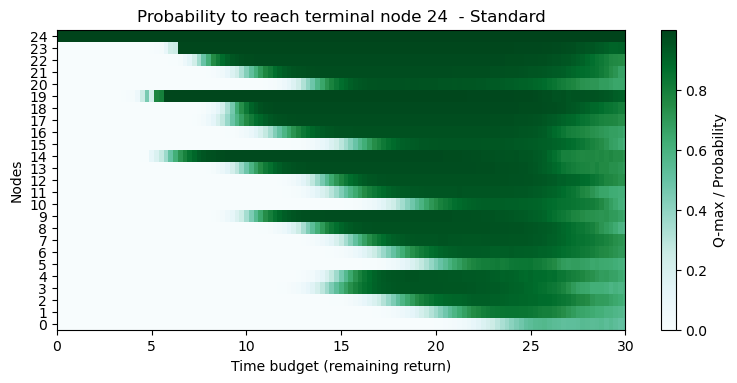

data loaded


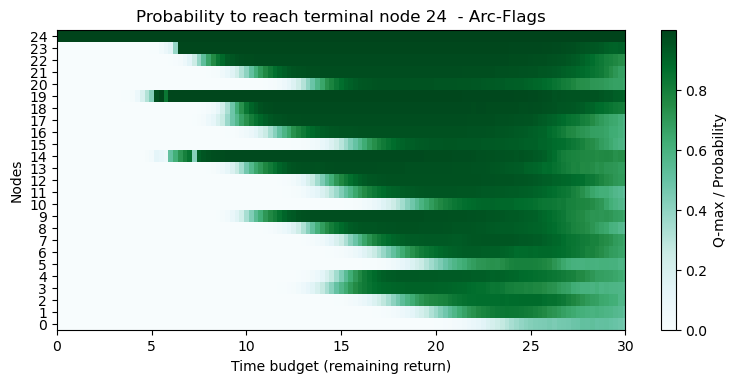

data loaded


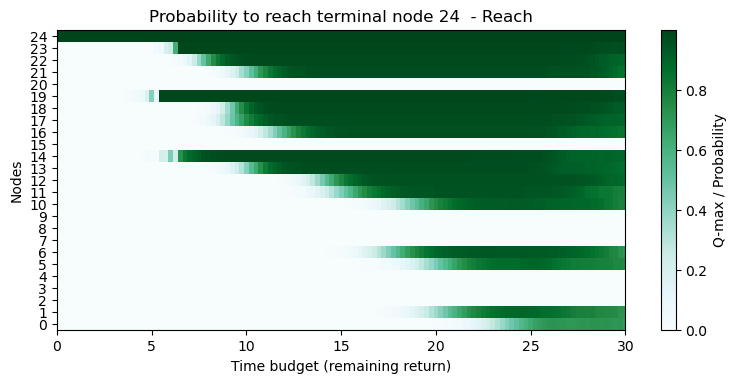

In [47]:
path_graph = "./../instances/graphs/5x5-1.pkl"
graph = Utils.load_object(path_graph)

plt1 = R2LPlot(graph, "./../instances/trained/grid_5x5-1_30000k500k-gn.pkl")
plt1.probability_to_reach_terminal_node(30, " - Standard")
#plt1.probability_to_reach_terminal_node_different_starting_nodes()

plt2 = R2LPlot(graph, "./../instances/trained/grid_5x5-1_30000k500k-af.pkl")
plt2.probability_to_reach_terminal_node(30, " - Arc-Flags")

plt3 = R2LPlot(graph, "./../instances/trained/grid_5x5-1_30000k500k-rh.pkl")
plt3.probability_to_reach_terminal_node(30, " - Reach")

In [26]:
path_graph = "./../instances/graphs/5x5-1.pkl"

path_gn = "./../instances/trained/grid_5x5-1_20000k500k-gn.pkl"
path_af = "./../instances/trained/grid_5x5-1_20000k500k-af.pkl"
path_rh = "./../instances/trained/grid_5x5-1_20000k500k-rh.pkl"

R2LTestFunctions.gn_af_rh_path_comparison(path_graph, path_gn, path_af, path_rh, start_node = 23, 
                                          remaining_reward=25, dont_print=True, print_graph_path=False, print_graph_pruned=False)

======== STANDARD R2L =========

Object loaded from ./../instances/graphs/5x5-1.pkl
data loaded correctly.
SOTA path: [23, 24]
Probability Q-value: 0.9609524527013679

======== ARC-FLAGS R2L ========

Object loaded from ./../instances/graphs/5x5-1.pkl
Partitioning of the graph in 4 regions executed in 0.0030 seconds!
Arcflags computed!...
[ArcFlags] Pruned 9 edges for destination 24 (region 0).
Arcflags computed and graph pruned in 0.0092s
data loaded correctly.
SOTA path: [23, 24]
Probability Q-value: 0.9619706444511126

======== REACH R2L ========

Object loaded from ./../instances/graphs/5x5-1.pkl
Reach values computeds...
Pruning nodes...Reach values computed and graph pruned (8 nodes) in 0.0115s
data loaded correctly.
SOTA path: [23, 24]
Probability Q-value: 0.9847025976514902


Object loaded from ./../instances/graphs/5x5-1.pkl
data loaded


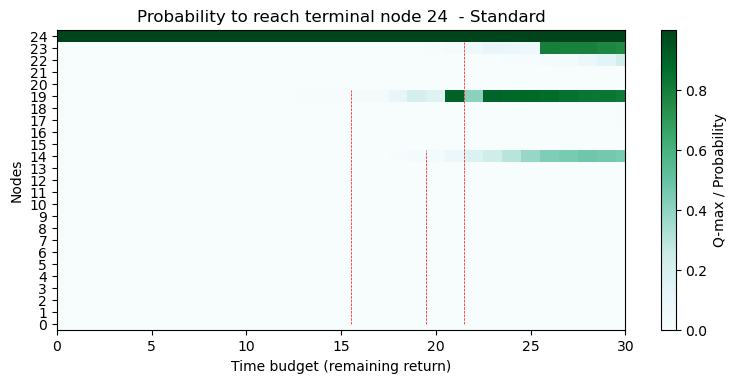

data loaded


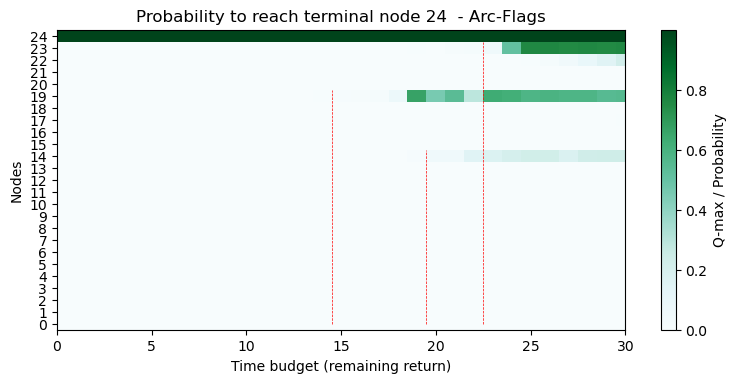

data loaded


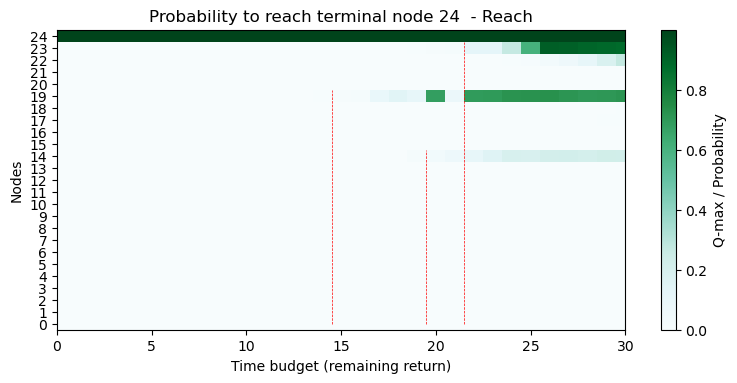

In [45]:
path_graph = "./../instances/graphs/5x5-1.pkl"
graph = Utils.load_object(path_graph)

plt1 = R2LPlot(graph, "./../instances/trained/grid_5x5-1_2000k200k-gn.pkl")
plt1.probability_to_reach_terminal_node(30, " - Standard", xy_lines=[(15.5, 19.5), (19.5, 14.5), (21.5, 23.5)])
#plt1.probability_to_reach_terminal_node_different_starting_nodes()

plt2 = R2LPlot(graph, "./../instances/trained/grid_5x5-1_2000k200k-af.pkl")
plt2.probability_to_reach_terminal_node(30, " - Arc-Flags", xy_lines=[(14.5,19.5), (19.5, 14.5), (22.5, 23.5)])

plt3 = R2LPlot(graph, "./../instances/trained/grid_5x5-1_2000k200k-rh.pkl")
plt3.probability_to_reach_terminal_node(30, " - Reach", xy_lines=[(14.5, 19.5), (19.5, 14.5), (21.5, 23.5)])

Object loaded from ./../instances/graphs/5x5-1.pkl
data loaded


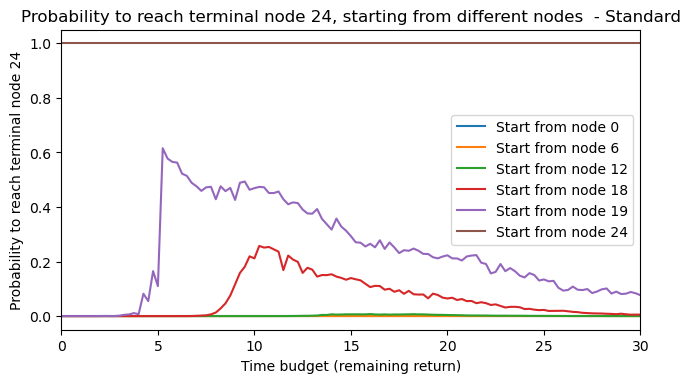

data loaded


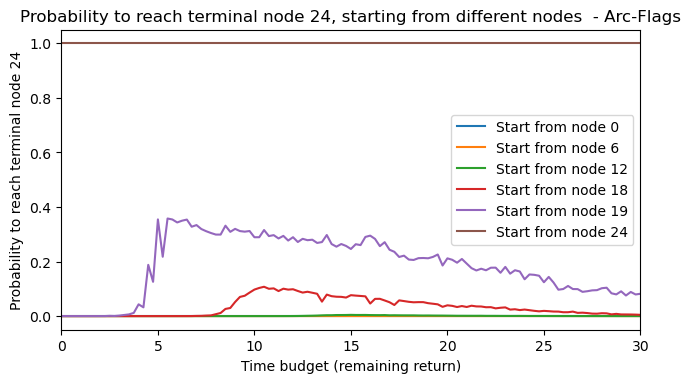

data loaded


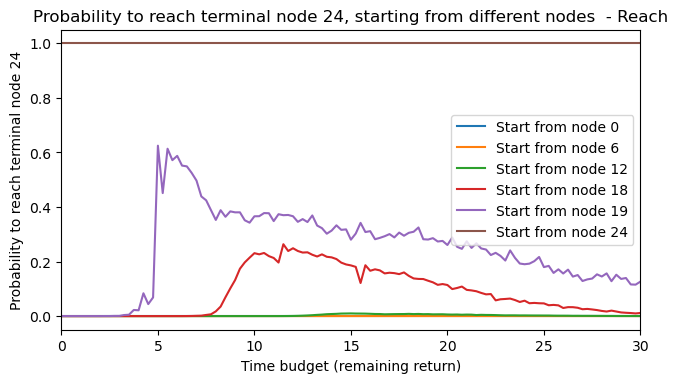

data loaded


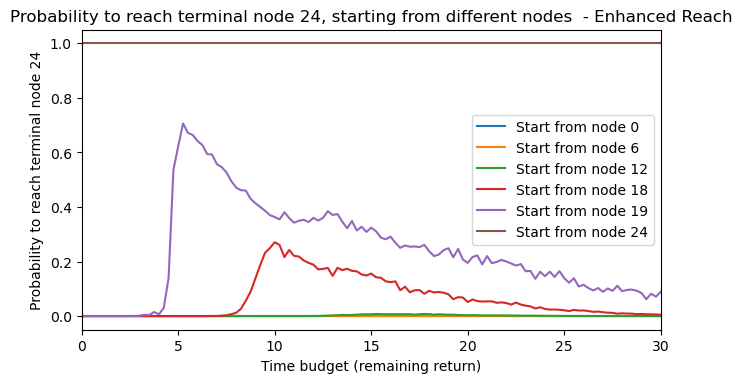

In [14]:
path_graph = "./../instances/graphs/5x5-1.pkl"
graph = Utils.load_object(path_graph)

plt1 = R2LPlot(graph, "./../instances/trained/grid_5x5-1_1000k100k-gn.pkl")
plt1.probability_to_reach_terminal_node_different_starting_nodes(30, " - Standard")

plt2 = R2LPlot(graph, "./../instances/trained/grid_5x5-1_1000k100k-af.pkl")
plt2.probability_to_reach_terminal_node_different_starting_nodes(30, " - Arc-Flags")

plt3 = R2LPlot(graph, "./../instances/trained/grid_5x5-1_1000k100k-rh.pkl")
plt3.probability_to_reach_terminal_node_different_starting_nodes(30, " - Reach")

plt4 = R2LPlot(graph, "./../instances/trained/grid_5x5-1_1000k100k-erh.pkl")
plt4.probability_to_reach_terminal_node_different_starting_nodes(30, " - Enhanced Reach")

In [94]:
graph_path = "./../instances/graphs/5x5-1.pkl"
path_erh = "./../instances/trained/grid_5x5-1_250k25k-erh-plus.pkl"

R2LTestFunctions.train_run(graph_path, "embedded_reach", episode_number=250000, episode_lissage=25000, path_save=path_erh)

Object loaded from ./../instances/graphs/5x5-1.pkl
Reach values computeds...
Pruning nodes...Episode =  25000 ----------  Error norm sup =  1 ----------  Error norm 1 =  1
step_nbr =  2.5098923984727524
Episode =  50000 ----------  Error norm sup =  1.2719475124313042e-07 ----------  Error norm 1 =  1.0308311607798242e-09
step_nbr =  3.0476610767872905
Episode =  75000 ----------  Error norm sup =  0.03691031544053124 ----------  Error norm 1 =  0.000710725635232445
step_nbr =  2.9726151068311766
Episode =  100000 ----------  Error norm sup =  0.03219342644462462 ----------  Error norm 1 =  0.0007280950566088207
step_nbr =  3.1079798279442303
Episode =  125000 ----------  Error norm sup =  0.04377165718360787 ----------  Error norm 1 =  0.0007494487890450296
step_nbr =  2.978767325272781
Episode =  150000 ----------  Error norm sup =  0.04009113273605808 ----------  Error norm 1 =  0.0007608598883004164
step_nbr =  3.023352054389595
Episode =  175000 ----------  Error norm sup =  0.039

127.406094789505

In [145]:
graph_path = "./../instances/graphs/5x5-1.pkl"
path_gn = "./../instances/trained/grid_5x5-1_100k10k-gn.pkl"
path_rh = "./../instances/trained/grid_5x5-1_100k10k-rh.pkl"
path_erh = "./../instances/trained/grid_5x5-1_100k10k-erh.pkl"

R2LTestFunctions.gn_rh_erh_path_comparison(graph_path, path_gn, path_rh, path_erh, 
                          start_node=11, remaining_reward=29, dont_print=True, print_graph_path=False)

========= STANDARD R2L ==========

Object loaded from ./../instances/graphs/5x5-1.pkl
data loaded correctly.
SOTA path: [11, 6, 1, 2, 2]
Probability Q-value: 0.0

========== REACH R2L ==========

Object loaded from ./../instances/graphs/5x5-1.pkl
Reach values computeds...
Pruning nodes...Reach values computed and graph pruned (8 nodes) in 0.0130s
data loaded correctly.
SOTA path: [11, 12, 17, 22, 17, 22, 23, 24]
Probability Q-value: 1.233027262265614e-15

===== EMBEDDED REACH R2L ======

Object loaded from ./../instances/graphs/5x5-1.pkl
Reach values computeds...
data loaded correctly.
SOTA path: [11, 6, 11, 12, 17, 18, 23, 22, 23, 24]
Probability Q-value: 0.0


========= STANDARD R2L ==========

Object loaded from ./../instances/graphs/5x5-1.pkl
data loaded correctly.
SOTA path: [2, 2]
Probability Q-value: 0.0


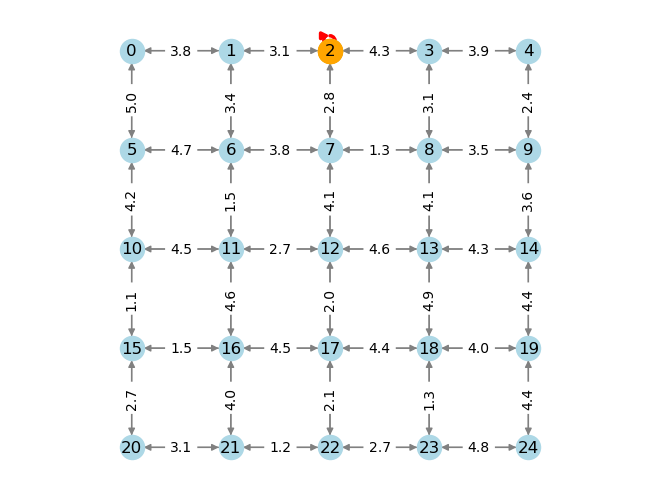


===== EMBEDDED REACH R2L ======

Object loaded from ./../instances/graphs/5x5-1.pkl
Reach values computeds...
data loaded correctly.
SOTA path: [2, 7, 8, 9, 8, 3, 3]
Probability Q-value: 1.5924774318073238e-19


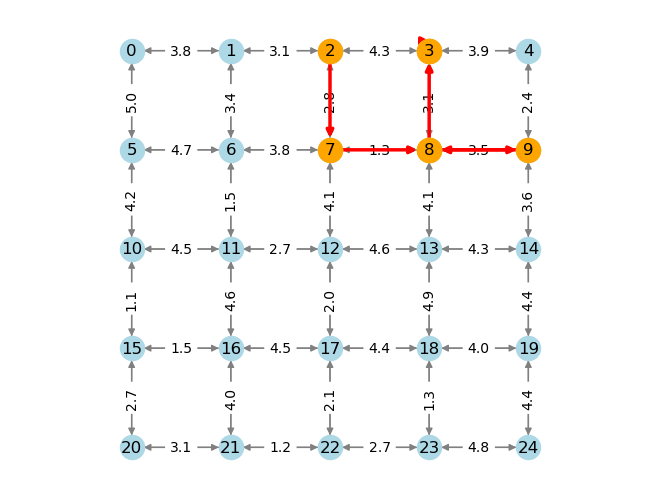


=== EMBEDDED REACH PLUS R2L ===

Object loaded from ./../instances/graphs/5x5-1.pkl
Reach values computeds...
data loaded correctly.
SOTA path: [2, 2]
Probability Q-value: 0.0


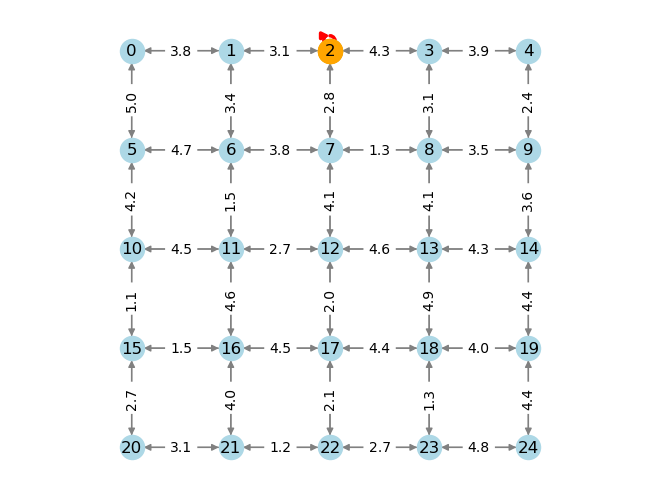

In [128]:
graph_path = "./../instances/graphs/5x5-1.pkl"
path_gn = "./../instances/trained/grid_5x5-1_100k10k-gn.pkl"
path_erh = "./../instances/trained/grid_5x5-1_100k10k-erh.pkl"
path_erh_plus = "./../instances/trained/grid_5x5-1_100k10k-erh-plus50.pkl"

R2LTestFunctions.gn_erh_erhplus_path_comparison(graph_path, path_gn, path_erh, path_erh_plus, 
                          start_node=2, remaining_reward=29, dont_print=True, print_graph_path=True)

Object loaded from ./../instances/graphs/5x5-1.pkl
Reach values computeds...
Pruning nodes...

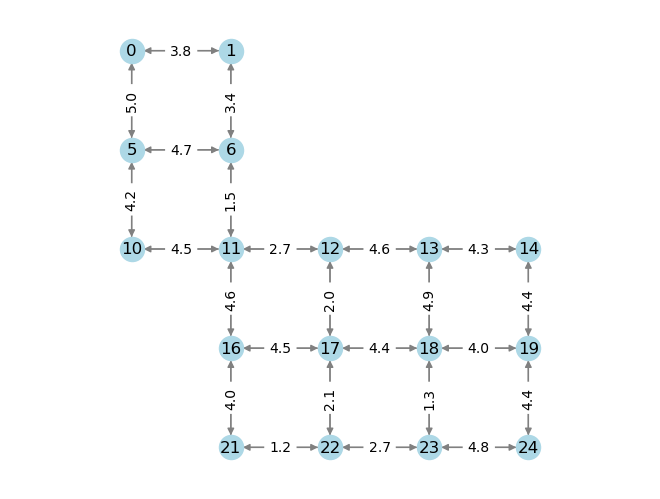

Pruning nodes...

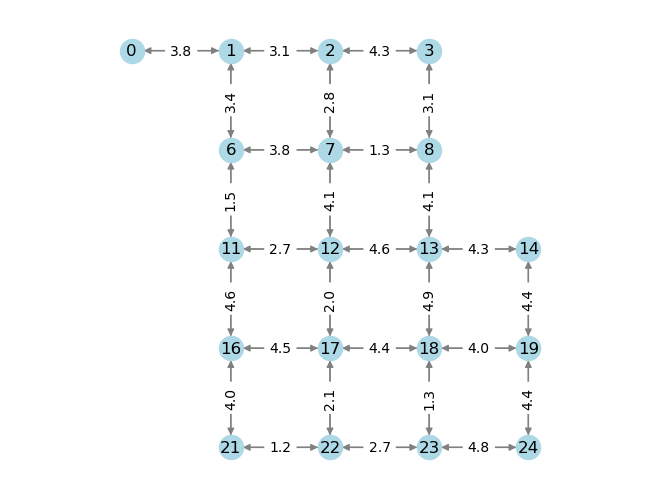

Pruning nodes...

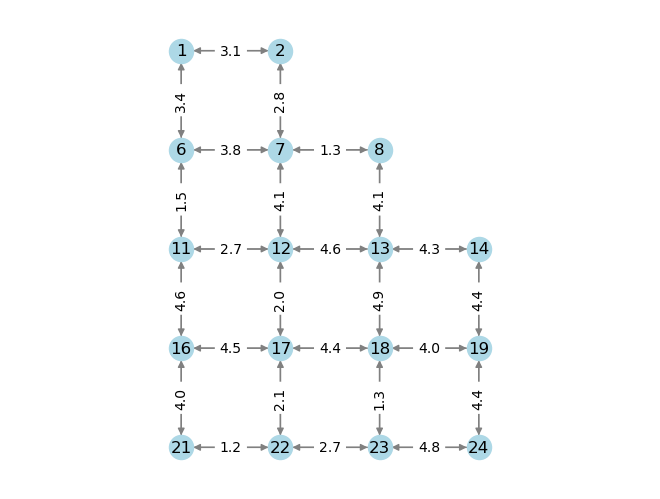

Pruning nodes...

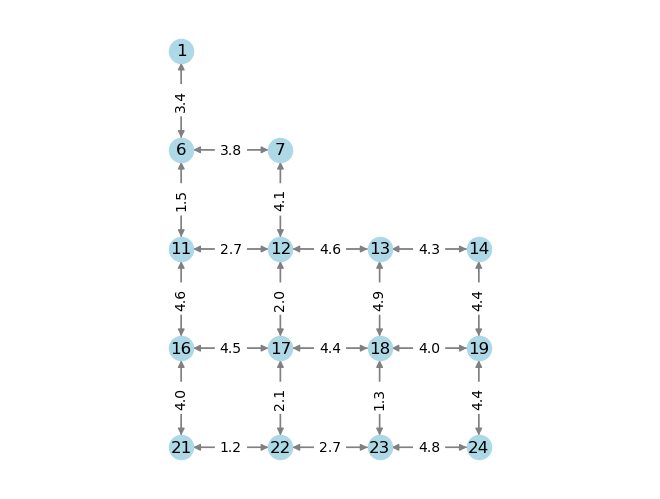

Pruning nodes...

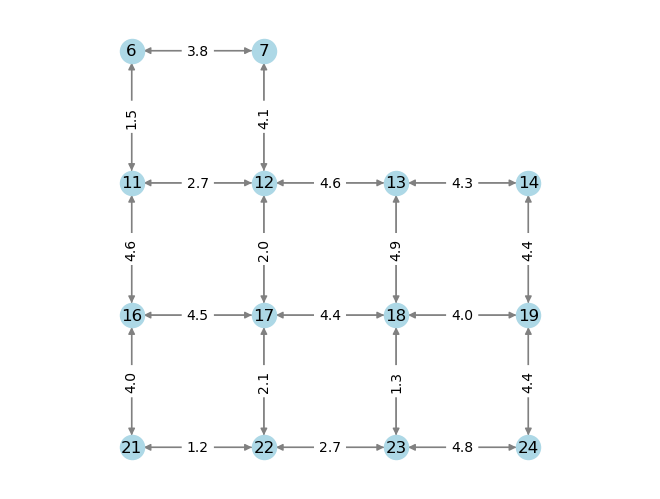

Pruning nodes...

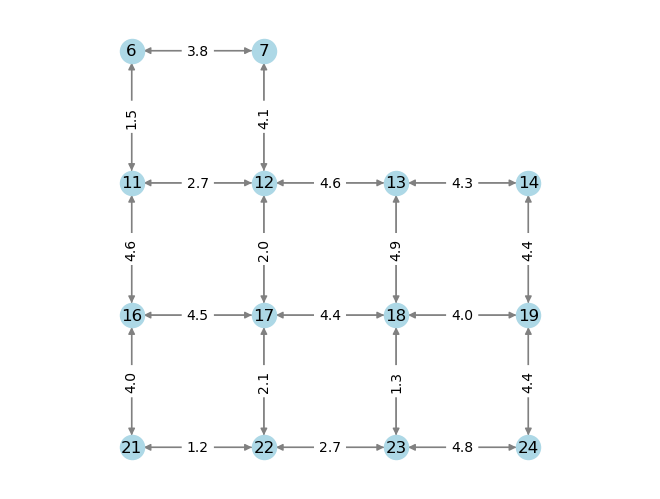

Pruning nodes...

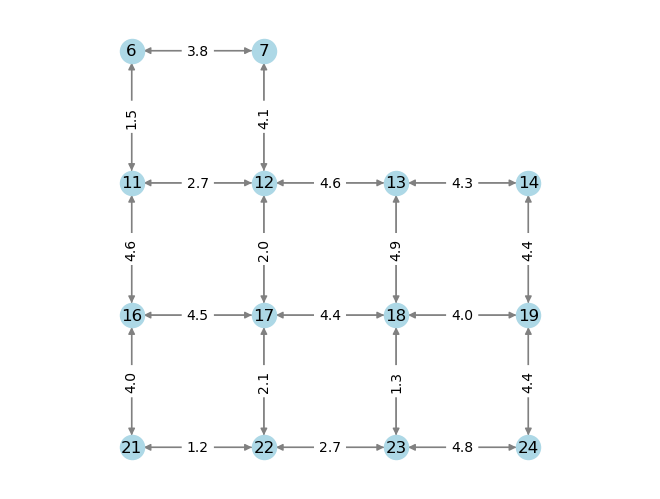

In [24]:
graph = Utils.load_object("./../instances/graphs/5x5-1.pkl")
d = Dijkstra(graph.get_adjacency_matrix())
r = detReach(graph, d)
r.reach_computation()
r.reach_pruning(0, 24)
r.print_graph()

r.reset_graph()
r.reach_pruning(1, 24)
r.print_graph()

r.reset_graph()
r.reach_pruning(6, 24)
r.print_graph()

r.reset_graph()
r.reach_pruning(11, 24)
r.print_graph()

r.reset_graph()
r.reach_pruning(12, 24)
r.print_graph()

r.reset_graph()
r.reach_pruning(17, 24)
r.print_graph()

r.reset_graph()
r.reach_pruning(22, 24)
r.print_graph()